In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import lines as mlines
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.kernel_ridge import KernelRidge

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge

### KNNR + Hyperparameter tuning 

In [ ]:
df = pd.read_excel('/Users/theresewild/Sigman Group Dropbox/Therese Wild/NN_Library/nn_ligand_modeling_datasets/all_single_stereochem_series/final/updated_basis_fluor/fluoride_modeling_properties_updated_bs_w_experimental_data_3.3.26.xlsx',
                   sheet_name='CS2_combined_ddg', header=1)

df_train = df[df['set'] == 'train']
df_internal_test = df[df['set'] == 'validation']
df_external_test = df[df['set'] == 'test']

df_exp_train = df_train.iloc[:,0:16]
df_features_train = df_train.iloc[:,16:]
feature_columns = df_features_train.columns

df_exp_internal_test = df_internal_test.iloc[:,0:16]
df_features_internal_test = df_internal_test.iloc[:,16:]

df_exp_external_test = df_external_test.iloc[:,0:16]
df_features_external_test = df_external_test.iloc[:,16:]

Shape of descriptors file before removing parameters with R^2 > 0.7 : (32, 521)
Shape of descriptors file after removing parameters with R^2 > 0.7 :  (32, 20)


In [ ]:
threshold = 0.7

# remove collinear features 
print(f'Shape of descriptors file before removing parameters with R^2 > {threshold} :',df_features_train.shape)
df_corr = df_features_train.corr()
df_not_correlated = ~(df_corr.mask(np.tril(np.ones([len(df_corr)]*2, dtype=bool))).abs() > threshold).any()
un_corr_idx = df_not_correlated.loc[df_not_correlated[df_not_correlated.index] == True].index
df_features_train = df_features_train[un_corr_idx]
df_features_internal_test = df_features_internal_test[un_corr_idx]
df_features_external_test = df_features_external_test[un_corr_idx]
print(f'Shape of descriptors file after removing parameters with R^2 > {threshold} : ',df_features_train.shape)


In [ ]:
df_features_train_scaled = pd.DataFrame(scaler.fit_transform(df_features_train), columns=df_features_train.columns)
df_features_internal_test_scaled = pd.DataFrame(scaler.transform(df_features_internal_test), columns=df_features_internal_test.columns)
df_features_external_test_scaled = pd.DataFrame(scaler.transform(df_features_external_test), columns=df_features_external_test.columns)

train_scaled = pd.concat([df_exp_train.reset_index(drop=True), df_features_train_scaled.reset_index(drop=True)], axis=1)
internal_test_scaled = pd.concat([df_exp_internal_test.reset_index(drop=True), df_features_internal_test_scaled.reset_index(drop=True)], axis=1)
external_test_scaled = pd.concat([df_exp_external_test.reset_index(drop=True), df_features_external_test_scaled.reset_index(drop=True)], axis=1)

df_scaled = pd.concat([train_scaled, internal_test_scaled, external_test_scaled], axis=0).reset_index(drop=True)

Selected feature indices: [ 1  3  9 14 15]
Selected feature names: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_Boltz', '%Vbur_Ni_octant_+,–,–_Boltz', 'NMR_shift_C1_Boltz']
0.9784962556584856 0.45451035338201595
0.05343460494215957 0.44336860363289315


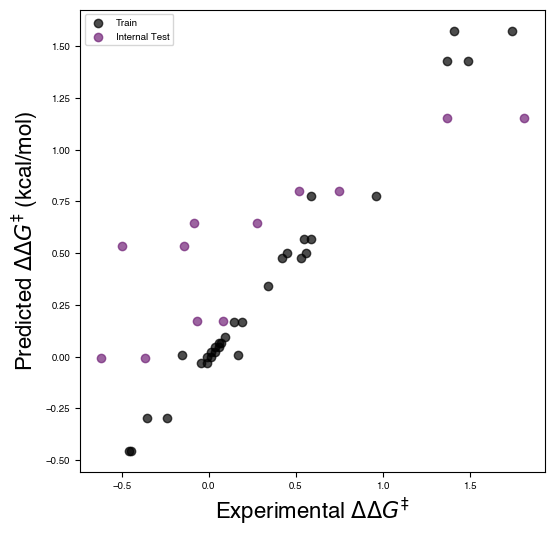

In [ ]:
X_train = df_features_train_scaled
y_train = (train_scaled['ddg_flipped'])
y_train = pd.to_numeric(y_train, errors='coerce').astype(float)
y_train_labels = train_scaled['ligandID']

X_internal_test = df_features_internal_test_scaled
y_internal_test = (internal_test_scaled['ddg_flipped'])
y_internal_test = pd.to_numeric(y_internal_test, errors='coerce').astype(float)
y_internal_test_labels = internal_test_scaled['ligandID']

X_external_test = df_features_external_test_scaled
y_external_test = (external_test_scaled['ddg_flipped'])
y_external_test = pd.to_numeric(y_external_test, errors='coerce').astype(float)
y_external_test_labels = external_test_scaled['ligandID']

k = 5
selector = SelectKBest(score_func=f_regression, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_internal_test_selected = selector.transform(X_internal_test)
X_external_test_selected = selector.transform(X_external_test)

# X_train_selected = X_train[['LUMO_Boltz', 'dipole(Debye)_Boltz', 'distance_N2_Ni(Å)_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_min', 'Buried_Sterimol_B5_N2_C2_5.0(Å)_Boltz', 'rxn']]
# X_internal_test_selected = X_internal_test[['LUMO_Boltz', 'dipole(Debye)_Boltz', 'distance_N2_Ni(Å)_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_min', 'Buried_Sterimol_B5_N2_C2_5.0(Å)_Boltz', 'rxn']]
# X_external_test_selected = X_external_test[['LUMO_Boltz', 'dipole(Debye)_Boltz', 'distance_N2_Ni(Å)_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_min', 'Buried_Sterimol_B5_N2_C2_5.0(Å)_Boltz', 'rxn']]

selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X_train.columns[selected_feature_indices]

print("Selected feature indices:", selected_feature_indices)
print("Selected feature names:", selected_feature_names.tolist())

knn = KNeighborsRegressor(n_neighbors=10, weights='distance' , p=1)
knn.fit(X_train_selected, y_train)
score_internal_test = knn.score(X_internal_test_selected, y_internal_test)
score_external_test = knn.score(X_external_test_selected, y_external_test)

y_train_pred = knn.predict(X_train_selected)
y_internal_test_pred = knn.predict(X_internal_test_selected)
y_external_test_pred = knn.predict(X_external_test_selected)

r2_train = knn.score(X_train_selected, y_train)
r2_internal_test = knn.score(X_internal_test_selected, y_internal_test)
r2_external_test = knn.score(X_external_test_selected, y_external_test)

mae_train = np.mean(np.abs(y_train - y_train_pred))
mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))
print (r2_train, r2_internal_test)
print (mae_train, mae_internal_test)

df_predictions_train = pd.DataFrame({
    'true_value': y_train,
    'predicted_value_knn': y_train_pred,
    'ligandID': y_train_labels,
    'set': 'train'
})

df_predictions_internal_test = pd.DataFrame({
    'true_value': y_internal_test,
    'predicted_value_knn': y_internal_test_pred,
    'ligandID': y_internal_test_labels,
    'set': 'internal_test'
})

df_predictions_external_test = pd.DataFrame({
    'true_value': y_external_test,
    'predicted_value_knn': y_external_test_pred,
    'ligandID': y_external_test_labels,
    'set': 'external_test'
})

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
# ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
ax.legend()

In [ ]:
df_predictions_knn = pd.concat([df_predictions_train, df_predictions_internal_test, df_predictions_external_test], axis=0).reset_index(drop=True)
df_predictions_knn

In [ ]:
df_predictions_knn.to_excel('knn_predictions_cs2_combined_ddg.xlsx', index=False)

### KRR + Hyperparameter Tuning

In [ ]:
df = pd.read_excel('/Users/theresewild/Sigman Group Dropbox/Therese Wild/NN_Library/nn_ligand_modeling_datasets/all_single_stereochem_series/final/updated_basis_fluor/fluoride_modeling_properties_updated_bs_w_experimental_data_3.3.26.xlsx',
                   sheet_name='CS2_combined_ddg', header=1)

df_train = df[df['set'] == 'train']
df_internal_test = df[df['set'] == 'validation']
df_external_test = df[df['set'] == 'test']

df_exp_train = df_train.loc[:,:'ligand_class']
df_features_train = df_train.loc[:,'HOMO_Boltz':]
feature_columns = df_features_train.columns

df_exp_internal_test = df_internal_test.loc[:,:'ligand_class']
df_features_internal_test = df_internal_test.loc[:,'HOMO_Boltz':]

df_exp_external_test = df_external_test.loc[:,:'ligand_class']
df_features_external_test = df_external_test.loc[:,'HOMO_Boltz':]

scaler = StandardScaler()
df_features_train_scaled = pd.DataFrame(scaler.fit_transform(df_features_train), columns=df_features_train.columns)
df_features_internal_test_scaled = pd.DataFrame(scaler.transform(df_features_internal_test), columns=df_features_internal_test.columns)
df_features_external_test_scaled = pd.DataFrame(scaler.transform(df_features_external_test), columns=df_features_external_test.columns)

train_scaled = pd.concat([df_exp_train.reset_index(drop=True), df_features_train_scaled.reset_index(drop=True)], axis=1)
internal_test_scaled = pd.concat([df_exp_internal_test.reset_index(drop=True), df_features_internal_test_scaled.reset_index(drop=True)], axis=1)
external_test_scaled = pd.concat([df_exp_external_test.reset_index(drop=True), df_features_external_test_scaled.reset_index(drop=True)], axis=1)

df_scaled = pd.concat([train_scaled, internal_test_scaled, external_test_scaled], axis=0).reset_index(drop=True)

##### CV To Select Optimal Number of Features for You

In [2]:
X_train = df_features_train_scaled # shuffle the training data
rng = np.random.RandomState(42)
shuffled_cols = rng.permutation(X_train.columns)
X_train = X_train[shuffled_cols]
X_train_df = df_features_train_scaled
y_train = (train_scaled['ddg_flipped'])
y_train_labels = (train_scaled['ligandID'])
y_train = pd.to_numeric(y_train, errors='coerce').astype(float)

X_internal_test = df_features_internal_test_scaled
X_internal_test = X_internal_test[shuffled_cols] # shuffle the internal test data in the same way as training data
y_internal_test = (internal_test_scaled['ddg_flipped'])
y_internal_test_labels = (internal_test_scaled['ligandID'])
y_internal_test = pd.to_numeric(y_internal_test, errors='coerce').astype(float)

X_external_test = df_features_external_test_scaled
X_external_test = X_external_test[shuffled_cols] # shuffle the external test data in the same way as training data
y_external_test = (external_test_scaled['ddg_flipped'])
y_external_test_labels = (external_test_scaled['ligandID'])
y_external_test = pd.to_numeric(y_external_test, errors='coerce').astype(float)

#picks optimal number of features for you
estimator = Ridge(alpha=0.3)
rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',        
    min_features_to_select=2 
)

X_train_selected = rfecv.fit_transform(X_train, y_train)
X_internal_test_selected = rfecv.transform(X_internal_test)
X_external_test_selected= rfecv.transform(X_external_test)

X_train = X_train_selected
X_internal_test = X_internal_test_selected
X_external_test = X_external_test_selected

selected_mask = rfecv.support_

selected_indices = np.where(selected_mask)[0]
selected_features = X_train_df.columns[selected_mask]

print("Optimal number of features:", rfecv.n_features_)
print("Selected feature indices:", selected_indices)
print("Selected feature names:", selected_features)

for kernel in ['polynomial', 'linear', 'rbf']:
    krr = KernelRidge(kernel=kernel, alpha=.7)
    krr.fit(X_train_selected, y_train)
    y_train_pred = krr.predict(X_train_selected)
    y_internal_test_pred = krr.predict(X_internal_test_selected)
    y_external_test_pred = krr.predict(X_external_test_selected)

    r2_train = krr.score(X_train_selected, y_train)
    r2_internal_test = krr.score(X_internal_test_selected, y_internal_test)
    r2_external_test = krr.score(X_external_test_selected, y_external_test)

    mae_train = np.mean(np.abs(y_train - y_train_pred))
    mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
    mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))

    df_predictions1_train = pd.DataFrame({'ligandID': y_train_labels,
                                         'true_ddg': y_train,
                                         'predicted_ddg_4_params': y_train_pred,
                                         'set': 'train'})
    df_predictions1_internal_test = pd.DataFrame({'ligandID': y_internal_test_labels,
                                                  'true_ddg': y_internal_test,
                                                  'predicted_ddg_4_params': y_internal_test_pred,
                                                  'set': 'internal_test'})

    df_predictions1_external_test = pd.DataFrame({'ligandID': y_external_test_labels,
                                                  'true_ddg': y_external_test,
                                                  'predicted_ddg_4_params': y_external_test_pred,
                                                  'set': 'external_test'})
    

    print (f'Kernel: {kernel}')
    print (f"R2 TTrain: {r2_train}, R2 Validation: {r2_internal_test}, R2 Test: {r2_external_test}")
    print (f"MAE Train: {mae_train}, MAE Validation: {mae_internal_test}", f"MAE Test: {mae_external_test}")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
    ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
    ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
    ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
    ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
    plt.show()

NameError: name 'df_features_train_scaled' is not defined

#### Selecting Optimal Number of Features Yourself

In [ ]:
#
X_train = df_features_train_scaled # shuffle the training data
rng = np.random.RandomState(42)
shuffled_cols = rng.permutation(X_train.columns)
X_train = X_train[shuffled_cols]
X_train_df = df_features_train_scaled
y_train = (train_scaled['ddg_flipped'])
y_train_labels = (train_scaled['ligandID'])
y_train = pd.to_numeric(y_train, errors='coerce').astype(float)

X_internal_test = df_features_internal_test_scaled
X_internal_test = X_internal_test[shuffled_cols] # shuffle the internal test data in the same way as training data
y_internal_test = (internal_test_scaled['ddg_flipped'])
y_internal_test_labels = (internal_test_scaled['ligandID'])
y_internal_test = pd.to_numeric(y_internal_test, errors='coerce').astype(float)

X_external_test = df_features_external_test_scaled
X_external_test = X_external_test[shuffled_cols] # shuffle the external test data in the same way as training data
y_external_test = (external_test_scaled['ddg_flipped'])
y_external_test_labels = (external_test_scaled['ligandID'])
y_external_test = pd.to_numeric(y_external_test, errors='coerce').astype(float)


estimator = Ridge(alpha=.3)
selector = RFE(estimator, n_features_to_select=4)
X_train_selected = selector.fit_transform(X_train, y_train)
X_internal_test_selected = selector.transform(X_internal_test)
X_external_test_selected = selector.transform(X_external_test)

selected_mask = selector.support_

# Get indices of selected features
selected_indices = np.where(selected_mask)[0]

# Get feature names (assuming X_train is a DataFrame)
selected_features = X_train.columns[selected_mask]

print ("Selected feature indices:", selected_indices)
print ("Selected feature names:", selected_features)

for kernel in ['polynomial', 'linear', 'rbf']:
    krr = KernelRidge(kernel=kernel, alpha=.7)
    krr.fit(X_train_selected, y_train)
    y_train_pred = krr.predict(X_train_selected)
    y_internal_test_pred = krr.predict(X_internal_test_selected)
    y_external_test_pred = krr.predict(X_external_test_selected)

    r2_train = krr.score(X_train_selected, y_train)
    r2_internal_test = krr.score(X_internal_test_selected, y_internal_test)
    r2_external_test = krr.score(X_external_test_selected, y_external_test)

    mae_train = np.mean(np.abs(y_train - y_train_pred))
    mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
    mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))

    df_predictions1_train = pd.DataFrame({'ligandID': y_train_labels,
                                         'true_ddg': y_train,
                                         'predicted_ddg_4_lig_params': y_train_pred,
                                         'set': 'train'})
    df_predictions1_internal_test = pd.DataFrame({'ligandID': y_internal_test_labels,
                                                  'true_ddg': y_internal_test,
                                                  'predicted_ddg_4_lig_params': y_internal_test_pred,
                                                  'set': 'internal_test'})

    df_predictions1_external_test = pd.DataFrame({'ligandID': y_external_test_labels,
                                                  'true_ddg': y_external_test,
                                                  'predicted_ddg_4_lig_params': y_external_test_pred,
                                                  'set': 'external_test'})
    

    print (f'Kernel: {kernel}')
    print (f"R2 TTrain: {r2_train}, R2 Validation: {r2_internal_test}, R2 Test: {r2_external_test}")
    print (f"MAE Train: {mae_train}, MAE Validation: {mae_internal_test}", f"MAE Test: {mae_external_test}")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
    ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
    ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
    ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
    ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
    plt.show()

In [79]:
df_predictions_krr = pd.concat([df_predictions1_train, df_predictions1_internal_test, df_predictions1_external_test], axis=0).reset_index(drop=True)
df_predictions_krr.to_excel('/Users/theresewild/Sigman Group Dropbox/Therese Wild/NN_Library/nn_ligand_modeling_datasets/all_single_stereochem_series/final/updated_basis_fluor/krr_predictions_cs2_combined_ddg_4_param_homo_eta_steri_steri_flupped_ddg_update_params.xlsx', index=False)
display (df_predictions_krr)

,ligandID,true_ddg,predicted_ddg_4_lig_params,set
0,10,0.166975,0.135525,train
1,10,-0.154907,0.023447,train
2,14,0.340860,0.275118,train
3,15,0.094991,0.120084,train
4,16,0.059292,-0.013759,train
5,16,0.035556,0.014524,train
6,17,0.142870,0.154253,train
7,17,0.191219,0.192815,train
8,18,-0.353756,-0.271058,train
9,18,-0.240207,-0.269658,train


### SHAP Analysis + Plot CS2

In [ ]:
import shap 
X = X_train_selected
y = (train_scaled['ddg_flipped'])

model = krr 
model.fit(X, y)

background = shap.sample(X, 100)  # or X.iloc[:100]
explainer = shap.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(X)
shap_values_test= explainer(X_internal_test_selected)

shap_values_df = pd.DataFrame(shap_values, columns=X_train_selected.columns)

shap_values_test_df = pd.DataFrame(shap_values, columns=X_train_selected.columns)

# drop any shape values that are all 0
cols_to_drop = [col for col in shap_values_df.columns if (shap_values_df[col] == 0).all()]
shap_values_df = shap_values_df.drop(columns=cols_to_drop)
shap_values_test_df = shap_values_test_df.drop(columns=cols_to_drop)

shap_t_test = shap_values_df.T
shap_t_test['SHAP_avg_val'] = shap_t_test.mean(axis=1)
shap_t_test

avg = shap_t_test.pop('SHAP_avg_val')
shap_t_test_abs = shap_t_test.abs()
shap_t_test_abs['SHAP_avg_abs_val'] = shap_t_test_abs.mean(axis=1)
avg_abs = shap_t_test_abs.pop('SHAP_avg_abs_val')
shap_t_test.insert(0, 'SHAP_avg_val', avg)
shap_t_test_abs.insert(1, 'SHAP_avg_abs_val', avg_abs)
shap_t_test_abs

# shap_t_abs.to_excel('/Users/theresewild/Sigman Group Dropbox/Therese Wild/NN_Library/nn_ligand_modeling_datasets/all_single_stereochem_series/final/updated_basis_fluor/shap_feature_importance_4param_ddg_flip.xlsx')

100%|██████████| 12/12 [00:00<00:00, 1159.74it/s]


,0,SHAP_avg_abs_val,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,30,31
η_low_E,0.119133,0.344997,0.156126,0.361264,0.393586,0.105861,0.142327,0.076777,0.109895,0.447504,...,0.424578,0.437180,0.341494,0.356609,0.418468,0.420854,0.653233,0.641208,0.163494,0.197858
Sterimol_B1_Ni_N2(Å)_morfeus_max,0.051016,0.122716,0.051720,0.155404,0.163140,0.047059,0.061378,0.068615,0.045790,0.161998,...,0.076287,0.071540,0.065098,0.099822,0.056330,0.076710,0.255357,0.285039,0.051629,0.077849
Buried_Sterimol_B5_N1_Ni_5.0(Å)_min,0.055957,0.255594,0.065694,0.503547,0.528818,0.167932,0.174955,0.103685,0.168184,0.361061,...,0.155946,0.151789,0.057856,0.066462,0.186097,0.189972,0.602434,0.635074,0.185021,0.189782
rxn,0.006212,0.025631,0.012469,0.012316,0.008285,0.012092,0.019022,0.034084,0.011021,0.058853,...,0.011596,0.007674,0.012912,0.019902,0.000635,0.004473,0.029754,0.028101,0.016543,0.024008


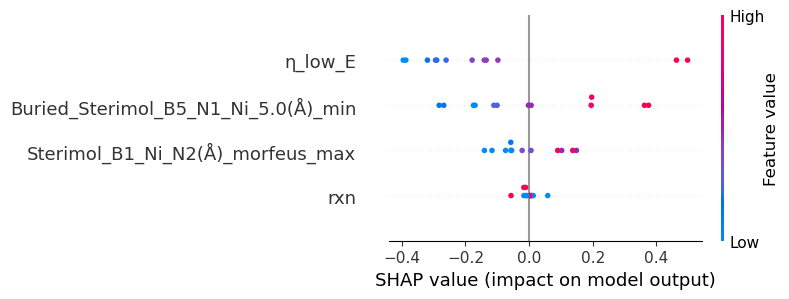

In [22]:
shap.summary_plot(
    shap_values_test,
    X_internal_test_selected,
    feature_names=X.columns,
    plot_type="dot",
    show=True
)
